# **Natural Language Processing**

Natural Language Processing (NLP) is a field of Artificial Intelligence that focuses on enabling computers to understand, process, and generate human language. In this hands-on exercise, you will implement a simple NLP pipeline in Python to preprocess text and explore fundamental techniques such as tokenization, normalization, and basic text analysis.

```
Raw Text
   ↓
Tokenization
   ↓
Cleaning / Normalization
   ↓
Stopword Removal
   ↓
Stemming / Lemmatization
   ↓
Feature Extraction (BoW / TF-IDF)
   ↓
NLP Application / ML

# Libraries

The following cell imports the Python libraries required for this hands-on exercise. If any of these libraries are not installed in your environment, you can install them using the command `pip install <library_name>`.


In [48]:
!pip install nltk pandas scikit-learn gensim seaborn scipy

In [49]:
# --- NLP ---
import nltk
from nltk.stem import PorterStemmer, LancasterStemmer, WordNetLemmatizer
from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import word_tokenize

# --- Data handling ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Text feature extraction ---
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import datasets, feature_extraction
import sklearn.manifold

# --- File and text processing ---
import glob
import codecs
import re

# --- Word embeddings ---
from gensim.models import Word2Vec

# --- Visualization ---
import seaborn as sns

In [50]:
# Download required NLTK datasets (run once if not already installed)

nltk.download('punkt')       # tokenizer models
nltk.download('punkt_tab')       # tokenizer models
nltk.download('stopwords')   # common stopwords list
nltk.download('wordnet')     # WordNet corpus for lemmatization

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# 1. Preprocessing techniques

Text preprocessing prepares raw text so it can be analyzed by NLP algorithms. It typically includes cleaning and transforming text using techniques such as tokenization, stopword removal, stemming, and lemmatization.


## 1.1. *Tokenization*

Tokenization is the process of splitting text into smaller units called tokens, such as words or sentences.

How can we tokenize a sentence or string?

In [51]:
# Example text
text = "Natural Language Processing (NLP) is an exciting field. Students at La Salle are learning it!"

# --- Sentence Tokenization ---
# Split the text into sentences (TO DO)
sentences = nltk.sent_tokenize(text)
print("Sentences:")
print(sentences)

# --- Word Tokenization ---
# Split the text into words/tokens (TO DO)
words = nltk.word_tokenize(text)
print("\nWords:")
print(words)

Sentences:
['Natural Language Processing (NLP) is an exciting field.', 'Students at La Salle are learning it!']

Words:
['Natural', 'Language', 'Processing', '(', 'NLP', ')', 'is', 'an', 'exciting', 'field', '.', 'Students', 'at', 'La', 'Salle', 'are', 'learning', 'it', '!']


If we want to use other languages, we need specific tokenizers:

In [52]:
# Example text in Spanish
sentence = "La inteligencia artificial está transformando la ingeniería y la ciencia de datos."

# --- Word Tokenization ---
# Split the text into words/tokens in Spanish (TO DO)
tokens = nltk.word_tokenize(sentence, language='spanish')

print(tokens)

['La', 'inteligencia', 'artificial', 'está', 'transformando', 'la', 'ingeniería', 'y', 'la', 'ciencia', 'de', 'datos', '.']


Now we will define a Python **function** that tokenizes the sentence it recives as a parameter:

In [53]:
# Function that splits a sentence into individual word tokens
def tokenize(sentence):
    return nltk.word_tokenize(sentence)

In [54]:
# Function call
tokenize("I don't know. I had to be something, didn't I?")

['I',
 'do',
 "n't",
 'know',
 '.',
 'I',
 'had',
 'to',
 'be',
 'something',
 ',',
 'did',
 "n't",
 'I',
 '?']

## 1.2. *Stemming*

Stemming reduces words to their root form by removing suffixes, often producing a simplified or truncated version of the word.

There are many models trained for word stemming in the `nltk` library:

* [Porter (1980)](http://snowball.tartarus.org/algorithms/porter/stemmer.html)
* [Lovins (1968)](http://snowball.tartarus.org/algorithms/lovins/stemmer.html)
* [Paice-Husk (1980)](https://en.wikipedia.org/wiki/Christopher_D._Paice#The_Paice-Husk_Stemming_Algorithm).

In [55]:
# Create a Porter stemmer (a common and balanced stemming algorithm)
porter = PorterStemmer()

# Create a Lancaster stemmer (a more aggressive stemming algorithm)
lancaster = LancasterStemmer()

In [56]:
# Sample words
words = [ "connection","connected","connecting","connections",
"relational","relativity","relate",
"studies","studying","studied",
"happiness","happy",
"care","caring","careful"
]

In [57]:
# Print table header
print("{0:20}{1:20}{2:20}\n".format("Word", porter.__class__.__name__, lancaster.__class__.__name__))

# Loop through words
for w in words:
  # Print word and stems using the stemmer (TO DO)
  print( "{0:20}{1:20}{2:20}".format(w, porter.stem(w), lancaster.stem(w)))

Word                PorterStemmer       LancasterStemmer    

connection          connect             connect             
connected           connect             connect             
connecting          connect             connect             
connections         connect             connect             
relational          relat               rel                 
relativity          rel                 rel                 
relate              relat               rel                 
studies             studi               study               
studying            studi               study               
studied             studi               study               
happiness           happi               happy               
happy               happi               happy               
care                care                car                 
caring              care                car                 
careful             care                car                 


## 1.3. *Lemmatization*

Lemmatization reduces words to their base or dictionary form (lemma) using linguistic rules and vocabulary knowledge.

The `nltk` library also has a lemmatizer model: [WordNet](https://wordnet.princeton.edu/).

In [ ]:
# Make the Lemmatizer (TO DO)
lemmatizer = WordNetLemmatizer()

# Download resources required for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')  # optional but recommended

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [59]:
# Example sentence
s = "The children were running faster than the mice and ate the cheeses."

# Tokenize sentence into words
words = nltk.word_tokenize(s)

In [60]:
# Print table header
print("{0:20}{1:20}\n".format("Word","Lemma"))

# Loop through words
for word in words:
    # Print word and lemma using the lemmatizer (TO DO)
    print("{0:20}{1:20}".format(word, lemmatizer.lemmatize(word)))

Word                Lemma               

The                 The                 
children            child               
were                were                
running             running             
faster              faster              
than                than                
the                 the                 
mice                mouse               
and                 and                 
ate                 ate                 
the                 the                 
cheeses             cheese              
.                   .                   


But there are not many changes here...

We need to specify the **part of speech** to lemmatize to the model with the attribute `pos`

In [61]:
# Print table header
print("{0:20}{1:20}\n".format("Word","Lemma"))

# Loop through words
for word in words:
    # Print only the lemma of the VERBS (TO DO)
    print("{0:20}{1:20}".format(word, lemmatizer.lemmatize(word, pos="v")))

Word                Lemma               

The                 The                 
children            children            
were                be                  
running             run                 
faster              faster              
than                than                
the                 the                 
mice                mice                
and                 and                 
ate                 eat                 
the                 the                 
cheeses             cheese              
.                   .                   


## 1.4. *Stop Words*

Stop words are very common words (such as the, is, and, in) that are often removed from text because they carry little meaningful information for many NLP tasks.

`nltk` has a list of stopwords in many languages:

In [62]:
# Download the NLTK stopwords dataset
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [63]:
# Print the list of English stopwords (TO DO)
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [64]:
# Print the list of Spanish stopwords (TO DO)
print(stopwords.words('spanish'))

['de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus', 'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 'suyos', 'suyas', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 'vuestra', 'vuestros', 'vuestras', 'esos', 'esas', 'estoy', 'estás', 'está', 'estamos', 'estáis', 'están', 'e

If we want to filter them from a string, we first need to **tokenize** the sentence, and compare each token to the stop words dictionary:

In [65]:
# Example sentence
s = "This is an example of a sentence that contains a lot of very common words in the English language."

# Tokenize sentence into words
words = nltk.word_tokenize(s)

In [66]:
# Load English stopwords list (TO DO)
stop_words = stopwords.words('english')

In [67]:
# Function to remove stopwords from a sentence
def filter_stop_words(sentence, stop_words):
    filtered = []                # List for filtered words

    # Check each word in the sentence
    for word in sentence:

        # Keep word if not a stopword (TO DO)
        if word not in stop_words:
            filtered.append(word)

    return filtered              # Return filtered list

In [68]:
# Example sentence
s = "This is an example of a sentence that contains a lot of very common words in the English language."

# Tokenize sentence
tokens = tokenize(s)

# Remove stopwords
filtered = filter_stop_words(tokens, stop_words)

# Print filtered tokens
print(filtered)

['This', 'example', 'sentence', 'contains', 'lot', 'common', 'words', 'English', 'language', '.']


## 1.5. *POS Tagging*

Part-of-Speech (POS) tagging assigns a grammatical label (such as noun, verb, or adjective) to each word in a sentence based on its role in the sentence.

In [69]:
# Download POS tagging models and resources (run once)

nltk.download('averaged_perceptron_tagger')      # main POS tagging model
nltk.download('averaged_perceptron_tagger_eng')  # English-specific POS tagger
nltk.download('tagsets_json')                    # tag definitions and descriptions

# Tag reference:
# https://www.learntek.org/blog/categorizing-pos-tagging-nltk-python/

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to /root/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!


True

In [70]:
# Show explanation of the POS tag PRP (personal pronoun)
nltk.help.upenn_tagset('PRP')

PRP: pronoun, personal
    hers herself him himself hisself it itself me myself one oneself ours
    ourselves ownself self she thee theirs them themselves they thou thy us


In [71]:
# Sample sentence
sentence = "The students quickly solved the programming problem while the teacher explained the algorithm."

# Tokenize sentence (TO DO)
text = nltk.word_tokenize(sentence)

# Print POS tags (TO DO)
print(nltk.pos_tag(text))

[('The', 'DT'), ('students', 'NNS'), ('quickly', 'RB'), ('solved', 'VBD'), ('the', 'DT'), ('programming', 'NN'), ('problem', 'NN'), ('while', 'IN'), ('the', 'DT'), ('teacher', 'NN'), ('explained', 'VBD'), ('the', 'DT'), ('algorithm', 'NN'), ('.', '.')]


## Tags:
* NN — Noun (singular)
* NNS — Noun (plural)
* NNP — Proper noun (singular)
* NNPS — Proper noun (plural)
* VB — Verb (base form)
* VBD — Verb (past tense)
* VBG — Verb (gerund / present participle)
* VBN — Verb (past participle)
* VBP — Verb (present tense, non-3rd person singular)
* VBZ — Verb (present tense, 3rd person singular)
* JJ — Adjective
* JJR — Comparative adjective
* JJS — Superlative adjective
* RB — Adverb
* IN — Preposition or subordinating conjunction
* DT — Determiner
* PRP — Personal pronoun
* PRP$ — Possessive pronoun
* CC — Coordinating conjunction
* CD — Cardinal number
* UH — Interjection
...


## 1.6. Example of a simple chatbot

This example demonstrates a basic rule-based chatbot that uses NLP techniques such as tokenization, POS tagging, and lemmatization to analyze a user's question and generate an appropriate response based on predefined rules.

In [72]:
# Sample sentence
s = "How do you play tennis?"

# Tokenization
words = nltk.word_tokenize(s.lower())

In [73]:
# POS Tagging
tags = nltk.pos_tag(words)
print(tags)
nouns = [token for token, pos in tags if pos.startswith('N')]
verbs = [token for token, pos in tags if pos.startswith('V')]
adverbs = [token for token, pos in tags if pos.startswith('W')]

[('how', 'WRB'), ('do', 'VB'), ('you', 'PRP'), ('play', 'VB'), ('tennis', 'NN'), ('?', '.')]


In [74]:
# Lemmatization
print("{0:20}{1:20}".format("Word","Lemma"))
print("")
verbs_lemm = []
for verb in verbs:
    verbs_lemm.append(lemmatizer.lemmatize(verb, pos="v"))
    print ("{0:20}{1:20}".format(verb,lemmatizer.lemmatize(verb, pos="v")))

Word                Lemma               

do                  do                  
play                play                


In [75]:
# Print the parts of speech
print("Nouns:", nouns)
print("Verbs:", verbs_lemm)
print("Adverbs:", adverbs)

Nouns: ['tennis']
Verbs: ['do', 'play']
Adverbs: ['how']


These functions implement the response rules of the chatbot. Each function contains a dictionary with predefined information about different sports (football, tennis, and basketball), and when a noun from the user's question matches a key in the dictionary, the function prints the corresponding response such as a definition, scoring explanation, or where the sport is played.

In [76]:
# Show sport definition
def show_definition(nouns):
    # Dictionary of definitions
    rules = {
        'football': 'Football is a team sport played with an oval ball on a rectangular field, where two teams aim to score points by advancing the ball into the opposing team\'s end zone through running or passing, with each possession starting from a scrimmage and involving downs, while the defense tries to stop the offense and gain possession.',
        'tennis': 'Tennis is a racket sport played on a rectangular court, where two players or teams take turns serving and hitting a ball over a net, aiming to score points by making the ball land in the opponent\'s court.',
        'basketball': 'Basketball is a fast-paced team sport where two teams of five players each compete to score points by shooting the ball through the opponent\'s basket while following rules such as dribbling, passing, and defending within a designated court.'
    }

    # Check nouns in dictionary
    for noun in nouns:
        try:
            print(rules[noun])   # Print definition
        except:
            None                # Ignore if noun not found


# Show scoring rules
def show_scoring(nouns):
    # Dictionary of scoring rules
    rules = {
        'football': 'In football, teams score points by getting the ball into the opponent\'s end zone or kicking it through the goalposts.',
        'tennis': 'In tennis, points are scored by winning rallies, with games, sets, and matches determined by accumulating points through successful serves and rallies.',
        'basketball': 'In basketball, points are scored by shooting the ball through the opponent\'s basket, with field goals counting for two or three points and free throws for one point each.'
    }

    # Check nouns in dictionary
    for noun in nouns:
        try:
            print(rules[noun])   # Print scoring rule
        except:
            None                # Ignore if noun not found


# Show where the sport is played
def show_places(nouns):
    # Dictionary of places
    rules = {
        'football': 'Football is played on a rectangular field.',
        'tennis': 'Tennis is played on a rectangular court with a net.',
        'basketball': 'Basketball is played on a rectangular court with hoops at each end.'
    }

    # Check nouns in dictionary
    for noun in nouns:
        try:
            print(rules[noun])   # Print place info
        except:
            None                # Ignore if noun not found

In [77]:
# Apply rule-based responses
def apply_rules(wh_words, verbs_lemm, nouns):

  answered = False   # Track if a rule matched

  # Check question type
  if 'how' in wh_words:
      if 'play' in verbs_lemm:        # How to play
          show_definition(nouns)
          answered = True
      elif 'score' in verbs_lemm:     # How to score
          show_scoring(nouns)
          answered = True

  elif 'what' in wh_words:
      if 'rules' in nouns:            # Ask for rules
          nouns.remove('rules')
          show_definition(nouns)
          answered = True

  elif 'where' in wh_words:
      if 'play' in verbs_lemm:        # Ask where sport is played
          show_places(nouns)
          answered = True

  # Default response if no rule matched
  if not answered:
      print("Sorry, I don't understand the question.")

# Run rules with extracted words
apply_rules(adverbs, verbs_lemm, nouns)

Tennis is a racket sport played on a rectangular court, where two players or teams take turns serving and hitting a ball over a net, aiming to score points by making the ball land in the opponent's court.


Putting them together we create a simple chatbot.

Try these questions to the bot:
* "How do you play tennis"
* "How is football played?"
* "How to score in tennis?"
* "What are the basic rules of basketball?"
* "Where do you typically play tennis?"

In [78]:
# Simple rule-based chatbot
def chatbot():
    while True:  # Run continuously

        # Ask user for a question
        sentence = input("\nAsk a question about a sport (type 'exit' to quit): ")

        # Exit condition
        if sentence.lower() == "exit":
            print("Goodbye!")
            break

        # Tokenize sentence (TO DO)
        words = nltk.word_tokenize(sentence.lower())

        # POS tagging  (TO DO)
        tags = nltk.pos_tag(words)

        # Extract nouns  (TO DO)
        nouns = [token for token, pos in tags if pos.startswith('N')]

        # Extract verbs  (TO DO)
        verbs = [token for token, pos in tags if pos.startswith('V')]

        # Extract WH question words (TO DO)
        wh_words = [token for token, pos in tags if pos.startswith('W')]

        # Lemmatize verbs  (TO DO)
        verbs_lemm = []
        for verb in verbs:
            verbs_lemm.append(lemmatizer.lemmatize(verb, pos="v"))

        # Apply rule-based logic  (TO DO)
        apply_rules(wh_words, verbs_lemm, nouns)


# Start chatbot
chatbot()


Ask a question about a sport (type 'exit' to quit): exit
Goodbye!


# **2. Encoders**

Encoders convert text into numerical representations that machines can process, allowing NLP models to analyze and learn patterns from language data.

## 2.1. *One Hot Encoding*

One-hot encoding represents each word as a vector of zeros with a single one indicating the word’s position in the vocabulary.

How to create the One Hot encoding vectors of a sentence:

In [79]:
# Tokenize sentence into words
tokens = nltk.word_tokenize("The world is indeed comic")

In [80]:
# Convert tokens into one-hot encoded columns (TO DO)
pd.get_dummies(tokens)

,The,comic,indeed,is,world
0,True,False,False,False,False
1,False,False,False,False,True
2,False,False,False,True,False
3,False,False,True,False,False
4,False,True,False,False,False


## 2.2. *Count Vectorizer*

Count Vectorizer converts a collection of text documents into a matrix of word counts based on the vocabulary in the dataset.

We could create a Count Vectorizer by ourselves but... We can also use libraries. The Python library `sklearn` implements a  [Count Vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) model. If not given a specific vocabulary, the model uses its own tokenizer to build a vocabulary given an input sentence.

In [81]:
from sklearn.feature_extraction.text import CountVectorizer

# Example documents (a small corpus)
documents = [
    "I love NLP",
    "I love machine learning",
    "NLP is fun"
]

# Create the CountVectorizer object (TO DO)
vectorizer = CountVectorizer()

# Learn the vocabulary and transform the documents into vectors (TO DO)
X = vectorizer.fit_transform(documents)

# Print the vocabulary (unique words found in the corpus)
print("Vocabulary:")
print(vectorizer.get_feature_names_out())

# Convert the sparse matrix to a normal array so we can see the values
print("\nCount Matrix:")
print(X.toarray())

Vocabulary:
['fun' 'is' 'learning' 'love' 'machine' 'nlp']

Count Matrix:
[[0 0 0 1 0 1]
 [0 0 1 1 1 0]
 [1 1 0 0 0 1]]


# 2.3. Other encoders


### 2.3.1. TF-IDF

TF-IDF (Term Frequency–Inverse Document Frequency) is a technique that measures how important a word is in a document relative to a collection of documents, giving higher weight to words that appear frequently in a document but rarely across the dataset.

We will use the same `20newsgroup` dataset as used previously with the Bag of Words and the Logistic Regression:

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [83]:
# Example documents (small text corpus)
documents = [
    "I love NLP",
    "I love machine learning",
    "NLP is fun"
]

In [84]:
# Create the TF-IDF vectorizer
# This will convert text into numerical vectors using TF-IDF weighting (TO DO)
vectorizer = TfidfVectorizer()

# Learn the vocabulary and transform the documents
# Each document becomes a vector of TF-IDF scores (TO DO)
X = vectorizer.fit_transform(documents)

In [85]:
# Print the vocabulary (all unique words found in the documents)
print("Vocabulary:")
print(vectorizer.get_feature_names_out())

Vocabulary:
['fun' 'is' 'learning' 'love' 'machine' 'nlp']


In [86]:
# Convert the TF-IDF matrix to an array to display it clearly
print("\nTF-IDF Matrix:")
print(X.toarray())


TF-IDF Matrix:
[[0.         0.         0.         0.70710678 0.         0.70710678]
 [0.         0.         0.62276601 0.4736296  0.62276601 0.        ]
 [0.62276601 0.62276601 0.         0.         0.         0.4736296 ]]


### 2.3.2. *Word2Vec*

Word2Vec is a neural network–based method that learns vector representations (embeddings) of words such that words with similar meanings appear close together in the vector space.



In [87]:
from sklearn.manifold import TSNE

# Download required resources
nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [88]:
# Load a corpus from NLTK
text = gutenberg.raw('melville-moby_dick.txt')

In [89]:
# Tokenize words
tokens = word_tokenize(text.lower())

# Remove stopwords and punctuation
stop_words = set(stopwords.words('english'))
tokens = [w for w in tokens if w.isalpha() and w not in stop_words]

# Split into small sentences for Word2Vec training
sentences = [tokens[i:i+20] for i in range(0, len(tokens), 20)]

# Train Word2Vec model (TO DO)
model = Word2Vec(sentences, vector_size=50, window=5, min_count=10)

This code uses t-SNE (t-Distributed Stochastic Neighbor Embedding) to reduce the dimensionality of word vectors so they can be visualized in 2D.

In [90]:
# Select words to visualize
words = ["whale", "sea", "ship", "captain", "boat", "man", "water", "fish", "crew"]

# Keep only words that exist in the model vocabulary (TO DO)
valid_words = [w for w in words if w in model.wv]

# Get vectors
vectors = np.array([model.wv[w] for w in valid_words])

# t-SNE requires perplexity < number of samples
tsne = TSNE(n_components=2, perplexity=min(5, len(vectors)-1), random_state=0)
points = tsne.fit_transform(vectors)

This code plots the Word2Vec embeddings in 2D using t-SNE. Each point represents a word, and the word label is displayed next to its position. Words with similar meanings appear close to each other in the plot.

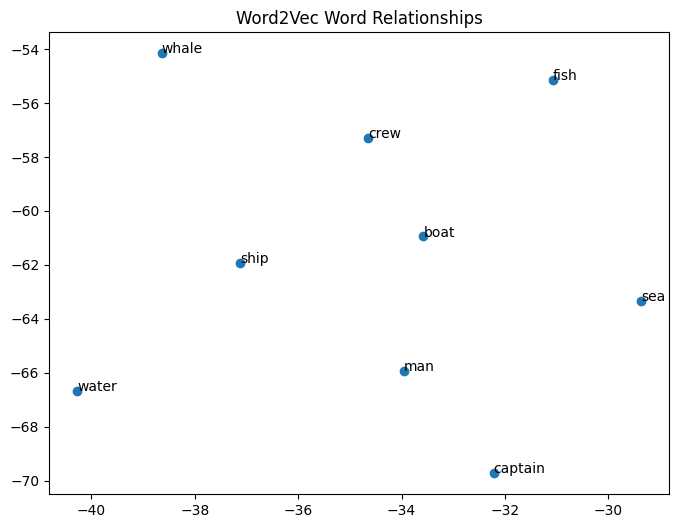

In [91]:
# Plot
plt.figure(figsize=(8,6))
plt.scatter(points[:,0], points[:,1])

for i, word in enumerate(valid_words):
    plt.annotate(word, (points[i,0], points[i,1]))

plt.title("Word2Vec Word Relationships")
plt.show()

#3. Sentiment Analysis

Sentiment analysis is an NLP technique used to determine whether a piece of text expresses a positive, negative, or neutral opinion. In this example, we use VADER, a rule-based sentiment analyzer from the NLTK library. The code analyzes movie reviews from the movie_reviews corpus, calculates sentiment scores (positive, negative, neutral, and compound), and uses the compound score to predict the overall sentiment of each review.


In [94]:
# Load Libraries and Corpus
import nltk
from nltk.corpus import movie_reviews
from nltk.sentiment import SentimentIntensityAnalyzer

# Downloads
nltk.download("movie_reviews")
nltk.download("vader_lexicon")

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [95]:
# Load VADER (TO DO)
sia = SentimentIntensityAnalyzer()

# Test VADER on a few movie reviews
for fileid in movie_reviews.fileids()[:5]:
    text = " ".join(movie_reviews.words(fileid))
    true_label = movie_reviews.categories(fileid)[0]

    # Get sentiment scores (TO DO)
    scores = sia.polarity_scores(text)

    print(text)
    print("True label:", true_label)
    print("VADER scores:", scores)
    print("Predicted sentiment:",
          "positive" if scores["compound"] >= 0.05 else
          "negative" if scores["compound"] <= -0.05 else
          "neutral")
    print("-" * 50)

plot : two teen couples go to a church party , drink and then drive . they get into an accident . one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . what ' s the deal ? watch the movie and " sorta " find out . . . critique : a mind - fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn ' t snag this one correctly . they seem to have taken this pretty neat concept , but executed it terribly . so what are the problems with the movie ? well , its main problem is that it ' s simply too jumbled . it starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience member , have no idea

#4. Word Cloud

This code creates a word cloud visualization from Shakespeare’s Hamlet. The most frequent words in the text appear larger, while less frequent words appear smaller, helping visualize the most important words in the corpus.

In [100]:
# Word Cloud using Shakespeare corpus

import nltk
import re
from nltk.corpus import gutenberg
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download corpus
nltk.download('gutenberg')

# Load Shakespeare's Hamlet
text = gutenberg.raw('shakespeare-hamlet.txt')

# remove non-letter characters
text = re.sub(r'[^a-zA-Z\s]', ' ', text)

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


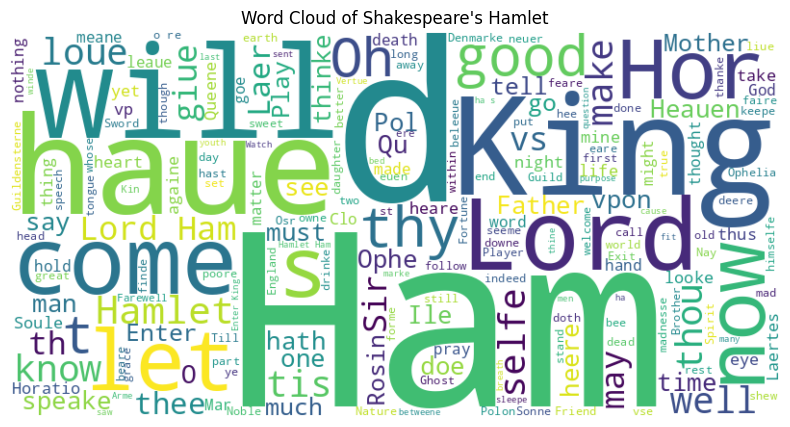

In [101]:
# Generate word cloud (TO DO)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Shakespeare's Hamlet")
plt.show()